In [1]:
import numpy as np
import os
from matplotlib import pyplot as plt
# progressbar
from progressbar import progressbar
# import test data
import pandas as pd
# for downloading pdb files
import urllib.request
import urllib.error
# import proaffinity inference module
from ProAffinity_GNN_inference import run_proaffinity_inference
# import ionerdss for surface contacting estimation
import sys 
sys.path.append( os.path.dirname( '/Users/msang/GitHub/ionerdss/ionerdss' ) )
import ionerdss as ion

In [2]:
def download_pdb_direct(pdb_id, download_dir="pdbfiles", verbose=False):
    """
    Direct download from RCSB PDB using urllib (alternative to Bio.PDB.PDBList)
    """
    if not os.path.exists(download_dir):
        os.makedirs(download_dir)
    
    clean_id = pdb_id.strip().lower()
    
    # Different URL formats for different file types
    url = f"https://files.rcsb.org/download/{clean_id}.pdb"
    filename = f"{clean_id}.pdb"
    
    filepath = os.path.join(download_dir, filename)
    
    try:
        # check if the file already existed
        if os.path.exists(filepath):
            if verbose: print(f"Existed file: {clean_id.upper()} from {url}...")
            return filepath
        else:
            if verbose: print(f"Downloading {clean_id.upper()} from {url}...")
            urllib.request.urlretrieve(url, filepath)
            # Check if file was downloaded and has content
            if os.path.exists(filepath) and os.path.getsize(filepath) > 0:
                if verbose: print(f"✓ Successfully downloaded: {filepath}")
                return filepath
            else:
                print(f"✗ Download failed or file is empty: {clean_id.upper()}")
                return None
            
    except urllib.error.HTTPError as e:
        if e.code == 404:
            print(f"✗ File not found (404): {clean_id.upper()}")
        else:
            print(f"✗ HTTP Error {e.code}: {clean_id.upper()}")
        return None
    except Exception as e:
        print(f"✗ Error downloading {clean_id.upper()}: {str(e)}")
        return None

In [3]:
def convert_pka_dG(pka, temperature=298.15):
    K = 10**pka
    R = 8.314 / 1000 # kJ/(mol*K)
    dG = -R * temperature * np.log(K)
    return dG



def kbt_to_kj_mol(dG, T_kelvin=298.15):
    """
    Convert k_B T to kJ/mol
    
    Parameters:
    temperature_celsius (float): Temperature in Celsius (default: 25°C)
    
    Returns:
    float: k_B T value in kJ/mol
    """
    
    k_B = 1.380649e-23  # Boltzmann constant in J/K
    N_A = 6.02214076e23  # Avogadro's number in mol^-1
    R = k_B * N_A  # Gas constant R = k_B * N_A = 8.314 J/(mol·K)

    kbt_joules = k_B * T_kelvin  # k_B T in Joules per particle
    kbt_kj_mol = kbt_joules * N_A / 1000  # Convert to kJ/mol
    return kbt_kj_mol * np.array(dG)

In [4]:
# unit conversion, and shift in ionerdss
kbt_to_kj_mol(1), kbt_to_kj_mol(2.27)

(2.4789570296023884, 5.6272324571974215)

In [5]:
def ionerdss_prediction(pdbfile, pdbid, chains):
    # get the energy of interfaces from coarse graining
    model = ion.PDBModel(pdb_file=pdbfile, save_dir=f'ionerdss/{pdbid}')
    model.coarse_grain()
    energy_dict = {}
    for i, chain in enumerate(model.all_chains):
        for j, interface in enumerate(model.all_interfaces[i]):
            pairname = ','.join(sorted([chain.id, interface]))
            energy_dict.update({pairname: round(model.all_interface_energies[i][j], 5)})
    # parse chains (in the format of 'XY,AB'
    chain_group_1, chain_group_2 = chains.split(',')
    chain_pairs = []
    for chain_i in chain_group_1:
        for chain_j in chain_group_2:
            chain_pairs.append( ','.join(sorted([chain_i, chain_j])) )
    # calculate total energy
    dG_tot = 0
    for pair in chain_pairs:
        if pair in energy_dict:
            dG_tot += energy_dict[pair]
        else:
            pass # No interface found by ionerdss
    return dG_tot

In [6]:
test_set_1 = pd.read_excel('ci4c01850_si_003.xls')
test_set_2 = pd.read_excel('ci4c01850_si_004.xls')

In [10]:
def filter_pdb_file(input_pdb_path, output_pdb_path):
    """
    Filters a PDB file to include only 'ATOM' records and keeps lines
    containing conventional amino acid or nucleic acid residue names.

    Args:
        input_pdb_path (str): The path to the input PDB file.
        output_pdb_path (str): The path to the output filtered PDB file.
    """

    # Define a set of standard/conventional amino acid and common nucleic acid residue names.
    # This list can be extended if other standard residues (e.g., modified standard ones)
    # or common ligands are considered "conventional" for a specific purpose.
    conventional_residues = {
        # Standard Amino Acids (3-letter codes)
        "ALA", "ARG", "ASN", "ASP", "CYS",
        "GLN", "GLU", "GLY", "HIS", "ILE",
        "LEU", "LYS", "MET", "PHE", "PRO",
        "SER", "THR", "TRP", "TYR", "VAL",
        # Common Nucleic Acids (DNA/RNA)
        "DA", "DC", "DG", "DT", # DNA
        "A", "C", "G", "U",    # RNA (often also used for DNA in some contexts)
        "T", # Thymine (sometimes used directly for DNA)
    }

#     print(f"Filtering PDB file: {input_pdb_path}")
#     print(f"Output will be saved to: {output_pdb_path}")
#     print(f"Keeping only conventional residues: {', '.join(conventional_residues)}")

    try:
        with open(input_pdb_path, 'r') as infile, \
             open(output_pdb_path, 'w') as outfile:
            for line in infile:
                # Check if the line starts with 'ATOM'
                if line.startswith("ATOM"):
                    # According to PDB format, residue name is usually columns 18-20 (1-indexed)
                    # which corresponds to indices 17-19 in a 0-indexed string.
                    # We strip to remove any leading/trailing whitespace from the extracted string.
                    residue_name = line[17:20].strip()

                    # Check if the residue name is in our list of conventional residues
                    if residue_name in conventional_residues:
                        outfile.write(line)
                    # else:
                    #     # Optional: print residues that are being removed for debugging
                    #     print(f"Removed unconventional residue '{residue_name}': {line.strip()}")
                elif line.startswith("TER"):
                    outfile.write(line)
                # Lines not starting with 'ATOM' are implicitly skipped by this logic.
                # (like HETATM for standard ligands),

    except FileNotFoundError:
        print(f"Error: Input file not found at {input_pdb_path}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


def pdb_to_pdbqt(pdbfile: str, ph: float = 7.4, verbose=False) -> str:
    """
    Converts a PDB file to a PDBQT file.

    This function first filters the input PDB file to include only 'ATOM' records,
    then uses Open Babel to convert this filtered PDB to PDBQT format,
    assigning EEM partial charges and adding hydrogens based on the specified pH.

    Args:
        pdbfile (str): The path to the input PDB file.
        ph (float): The pH value to use for adding hydrogens during conversion.
                    Defaults to 7.4.

    Returns:
        str: The path to the newly created PDBQT file.

    Raises:
        FileNotFoundError: If the input PDB file does not exist.
        subprocess.CalledProcessError: If 'grep' or 'obabel' commands fail.
        Exception: For other unexpected errors during file operations.
    """
    import subprocess
    import os
    if not os.path.exists(pdbfile):
        raise FileNotFoundError(f"Input PDB file not found: {pdbfile}")

    # Construct the output PDBQT filename
    # Replaces .pdb or .PDB with .pdbqt
    base_name, ext = os.path.splitext(pdbfile)
    pdbqtfile = f"{base_name}.pdbqt"

    # Create a temporary file to store only ATOM lines
    tmp_pdb_file = f"{base_name}_tmp.pdb"

    try:
        # Step 1: Grep only ATOM lines from the PDB file
        if verbose: print(f"Filtering ATOM lines from {pdbfile} to {tmp_pdb_file}...")
        filter_pdb_file(pdbfile, tmp_pdb_file)
        if verbose: print("ATOM lines filtered successfully.")

        # Step 2: Convert the temporary PDB file to PDBQT using obabel
        if verbose: print(f"Converting {tmp_pdb_file} to {pdbqtfile} using obabel...")
        # TODO: This has filtered only for ATOM. Also needs to remove non-classical residues like GLX
        obabel_command = [
            'prepare_receptor',
            '-r', 
            tmp_pdb_file,
            '-A', 'hydrogens', # Add hydrogens 
            '-o', pdbqtfile # write results to pdbqt
        ]
        # Run obabel, capturing output for debugging if needed
        result = subprocess.run(obabel_command, check=True, capture_output=True, text=True)
        if verbose: print("Obabel conversion successful.")
        if result.stdout:
            if verbose: print("Obabel stdout:\n", result.stdout)
        if result.stderr:
            if verbose: print("Obabel stderr:\n", result.stderr)

        if not os.path.exists(pdbqtfile):
            raise Exception(f"Obabel command ran without error but did not create {pdbqtfile}")

        return pdbqtfile

    except FileNotFoundError as e:
        print(f"Error: Command not found. Make sure 'grep' and 'obabel' are installed and in your PATH.")
        raise e
    except subprocess.CalledProcessError as e:
        print(f"Error during command execution:")
        print(f"Command: {' '.join(e.cmd)}")
        print(f"Return Code: {e.returncode}")
        print(f"Stdout: {e.stdout}")
        print(f"Stderr: {e.stderr}")
        raise e
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        raise e
    finally:
        # Clean up the temporary file
        if os.path.exists(tmp_pdb_file):
            os.remove(tmp_pdb_file)
            print(f"Successfully converted to pdbqt!")



In [11]:
def get_true_and_predictions(test_set, get_ionerdss=True, get_proaffinity=True):
    dG_proaffinity_test_set = []
    dG_ionerdss_test_set = []
    dG_true_test_set = []
    for row in test_set.itertuples():
        print(f'Processing {row.PDB.upper()} ...', end='\t')
        # get pdb file and parse data
        pdbfile = download_pdb_direct(row.PDB)
        chains = row._3.strip().rstrip(";").replace(';', ',')
        dG_true_test_set.append(convert_pka_dG(row.pKa))
        # ionerdss prediction
        if get_ionerdss:
            print('ionerdss ...', end='\t')
            dG_pred = ionerdss_prediction(pdbfile, row.PDB, chains)
            dG_ionerdss_test_set.append(dG_pred)
        else:
            pass
        # proaffinity predictions
        if get_proaffinity:
            print('proaffinity ...', end='\t')
            try:
                pdbqtfile = pdb_to_pdbqt(pdbfile)
                dG_pred = run_proaffinity_inference(pdbqtfile, chains)
                print(f"Successed! ")
            except Exception as e:
                dG_pred = np.nan
                print(f"Error!:\n", e)
            dG_proaffinity_test_set.append(dG_pred)
        else:
            print(f"Successed! ")
    return (np.array(dG_proaffinity_test_set), 
        np.array(dG_ionerdss_test_set), 
        np.array(dG_true_test_set))

In [12]:
dG_proaffinity_test_set_1 , dG_ionerdss_test_set_1, dG_true_test_set_1 = get_true_and_predictions(test_set_1, get_proaffinity=True, get_ionerdss=False)
# dG_proaffinity_test_set_2 , dG_ionerdss_test_set_2, dG_true_test_set_2 = get_true_and_predictions(test_set_2, get_proaffinity=False)

Processing 1WEJ ...	proaffinity ...	Successfully converted to pdbqt!


/home/local/WIN/msang2/anaconda3/lib/python3.11/site-packages/transformers/utils/generic.py:260: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/mnt/Data1/mankun/GitHub/ionerdss/proaffinity-gnn/ProAffinity_GNN_inference.py:747: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more detail

Successed! 
Processing 1PPE ...	proaffinity ...	Successfully converted to pdbqt!


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/mnt/Data1/mankun/GitHub/ionerdss/proaffinity-gnn/ProAffinity_GNN_inference.py:747: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user 

Successed! 
Processing 1PVH ...	proaffinity ...	Successfully converted to pdbqt!


...

Successed! 
Processing 2C0L ...	proaffinity ...	Successfully converted to pdbqt!


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/mnt/Data1/mankun/GitHub/ionerdss/proaffinity-gnn/ProAffinity_GNN_inference.py:747: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user 

Successed! 
Processing 1ATN ...	proaffinity ...	Successfully converted to pdbqt!


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/mnt/Data1/mankun/GitHub/ionerdss/proaffinity-gnn/ProAffinity_GNN_inference.py:747: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user 

Successed! 


In [13]:
from scipy.stats import pearsonr

# Calculate correlation and significance
# print('ionerdss:')
# correlation, p_value = pearsonr(dG_true_test_set_1, kbt_to_kj_mol(dG_ionerdss_test_set_1))
# print(f"Correlation: {correlation**2:.3f}")
# print(f"P-value: {p_value:.3f}")

print('ProAffinity:')
dG_true_test_set_1 = np.array(dG_true_test_set_1)
dG_proaffinity_test_set_1 = np.array(dG_proaffinity_test_set_1)
nans = np.isnan(dG_proaffinity_test_set_1)
correlation, p_value = pearsonr(dG_true_test_set_1[~nans], dG_proaffinity_test_set_1[~nans])
print(f"Correlation: {correlation**2:.3f}")
print(f"P-value: {p_value:.3f}")

ProAffinity:
Correlation: 0.455
P-value: 0.000


In [18]:
test_set_1.iloc[np.argwhere(nans==True)[0]]

,PDB,pKa,Pairwise interaction
60,1I4D,5.522879,D;AB


Text(0, 0.5, 'Predicted dG (kJ/mol)')

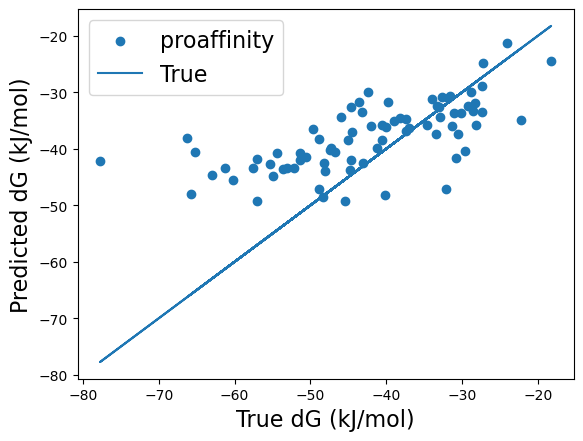

In [15]:
# plt.scatter(dG_true_test_set_1, kbt_to_kj_mol(dG_ionerdss_test_set_1), color='tab:orange', label='ionerdss')
plt.scatter(dG_true_test_set_1, dG_proaffinity_test_set_1, label='proaffinity')
plt.plot(dG_true_test_set_1, dG_true_test_set_1, label='True')
plt.legend(fontsize=16)
plt.xlabel('True dG (kJ/mol)', fontsize=16)
plt.ylabel('Predicted dG (kJ/mol)', fontsize=16)

In [97]:
len(dG_proaffinity_test_set_1), len(dG_true_test_set_1)

(79, 79)

Text(0, 0.5, 'Predicted dG (kJ/mol)')

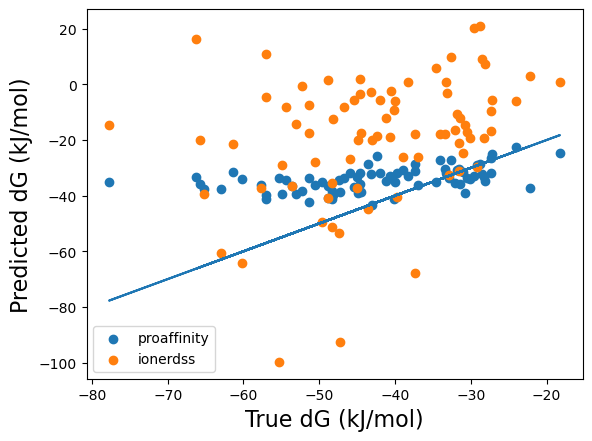

In [98]:
plt.scatter(dG_true_test_set_1, dG_proaffinity_test_set_1, label='proaffinity')
plt.scatter(dG_true_test_set_1, kbt_to_kj_mol(dG_ionerdss_test_set_1), label='ionerdss')
plt.plot(dG_true_test_set_1, dG_true_test_set_1)
plt.legend()
plt.xlabel('True dG (kJ/mol)', fontsize=16)
plt.ylabel('Predicted dG (kJ/mol)', fontsize=16)

In [ ]:
len(dG_proaffinity_test_set_2), len(dG_true_test_set_2)

Text(0, 0.5, 'Predicted dG (kJ/mol)')

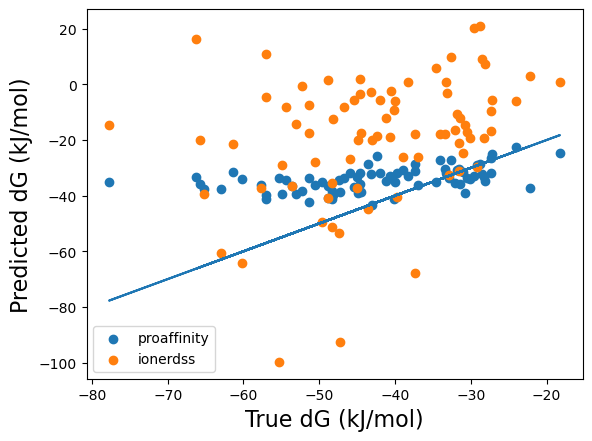

In [98]:
plt.scatter(dG_true_test_set_2, dG_proaffinity_test_set_2, label='proaffinity')
plt.scatter(dG_true_test_set_2, kbt_to_kj_mol(dG_ionerdss_test_set_2), label='ionerdss')
plt.plot(dG_true_test_set_2, dG_true_test_set_2)
plt.legend()
plt.xlabel('True dG (kJ/mol)', fontsize=16)
plt.ylabel('Predicted dG (kJ/mol)', fontsize=16)

In [7]:
def _get_default_energy_table():
    """Returns energy table for residue-residue interactions.

    Reference:
        Miyazawa, S., & Jernigan, R. L. (1996). Residue-residue potentials 
        with a favorable contact pair term and an unfavorable high packing density term,
        for simulation and threading. J Mol Biol, 256(3), 623–644.

    Returns:
        dict: A symmetric dictionary with residue pair tuples as keys and contact energies (in RT units) as values.
    """
    residues = [
        'CYS', 'MET', 'PHE', 'ILE', 'LEU', 'VAL', 'TRP', 'TYR', 'ALA', 'GLY',
        'THR', 'SER', 'ASN', 'GLN', 'ASP', 'GLU', 'HIS', 'ARG', 'LYS', 'PRO'
    ]

    # Extracted from the upper triangle of the table (manually transcribed)
    energy_matrix = [
        [-5.44],
        [-4.99, -5.46],
        [-5.80, -6.56, -7.26],
        [-5.50, -6.02, -6.84, -6.54],
        [-5.83, -6.41, -7.28, -7.04, -7.37],
        [-4.96, -5.32, -6.29, -6.05, -6.48, -5.52],
        [-4.95, -5.55, -6.16, -5.78, -6.14, -5.18, -5.06],
        [-4.16, -4.91, -5.66, -5.25, -5.67, -4.62, -4.66, -4.17],
        [-3.57, -3.94, -4.81, -4.58, -4.91, -4.04, -3.82, -3.36, -2.72],
        [-3.16, -3.39, -4.13, -3.78, -4.16, -3.38, -3.42, -3.01, -2.31, -2.24],
        [-3.11, -3.51, -4.28, -4.03, -4.34, -3.46, -3.22, -3.01, -2.32, -2.08, -2.12],
        [-2.86, -3.03, -4.02, -3.52, -3.92, -3.05, -2.99, -2.78, -2.01, -1.82, -1.96, -1.67],
        [-2.59, -2.95, -3.75, -3.24, -3.74, -2.83, -3.07, -2.76, -1.84, -1.74, -1.88, -1.58, -1.68],
        [-2.85, -3.30, -4.10, -3.67, -4.04, -3.07, -3.11, -2.97, -1.89, -1.66, -1.90, -1.49, -1.71, -1.54],
        [-2.41, -2.57, -3.48, -3.17, -3.40, -2.48, -2.84, -2.76, -1.70, -1.59, -1.80, -1.63, -1.68, -1.46, -1.21],
        [-2.27, -2.89, -3.56, -3.27, -3.59, -2.67, -2.99, -2.79, -1.51, -1.22, -1.74, -1.48, -1.51, -1.42, -1.02, -0.91],
        [-3.60, -3.98, -4.77, -4.14, -4.54, -3.58, -3.98, -3.52, -2.41, -2.15, -2.42, -2.11, -2.08, -1.98, -2.32, -2.15, -3.05],
        [-2.57, -3.12, -3.98, -3.63, -4.03, -3.07, -3.41, -3.16, -1.83, -1.72, -1.90, -1.62, -1.64, -1.80, -2.29, -2.27, -2.16, -1.55],
        [-1.95, -2.48, -3.36, -3.01, -3.37, -2.49, -2.69, -2.60, -1.31, -1.15, -1.31, -1.05, -1.21, -1.29, -1.68, -1.80, -1.35, -0.59, -0.12],
        [-3.07, -3.45, -4.25, -3.76, -4.20, -3.32, -3.73, -3.19, -2.03, -1.87, -1.90, -1.57, -1.53, -1.73, -1.33, -1.26, -2.25, -1.70, -0.97, -1.75]
    ]

    energy_table = {}

    for i, res_i in enumerate(residues):
        for j, res_j in enumerate(residues[:i+1]):
            energy = energy_matrix[i][j] + 2.27  # Adjusted energy value
            energy_table[(res_i, res_j)] = energy
            energy_table[(res_j, res_i)] = energy  # symmetry

    return energy_table

energy_table = _get_default_energy_table()


def convert_residue_codes(one_letter_tuple):
    """
    Convert a tuple of one-letter amino acid codes to three-letter codes.
    
    Args:
        one_letter_tuple: Tuple of one-letter amino acid codes (e.g., ('Q', 'E'))
    
    Returns:
        Tuple of three-letter amino acid codes (e.g., ('Gln', 'Glu'))
    """
    
    # Mapping dictionary from one-letter to three-letter codes
    aa_mapping = {
        'A': 'Ala',  # Alanine
        'C': 'Cys',  # Cysteine
        'D': 'Asp',  # Aspartic acid
        'E': 'Glu',  # Glutamic acid
        'F': 'Phe',  # Phenylalanine
        'G': 'Gly',  # Glycine
        'H': 'His',  # Histidine
        'I': 'Ile',  # Isoleucine
        'K': 'Lys',  # Lysine
        'L': 'Leu',  # Leucine
        'M': 'Met',  # Methionine
        'N': 'Asn',  # Asparagine
        'P': 'Pro',  # Proline
        'Q': 'Gln',  # Glutamine
        'R': 'Arg',  # Arginine
        'S': 'Ser',  # Serine
        'T': 'Thr',  # Threonine
        'V': 'Val',  # Valine
        'W': 'Trp',  # Tryptophan
        'Y': 'Tyr',  # Tyrosine
    }
    
    # Convert each one-letter code to three-letter code
    try:
        three_letter_codes = tuple(aa_mapping[code.upper()].upper() for code in one_letter_tuple)
        print('-'.join(three_letter_codes))
        return three_letter_codes
    except KeyError as e:
        raise ValueError(f"Invalid amino acid code: {e}")

In [9]:
pdbid = '8y7s'
print(f'Processing {pdbid.upper()} ...', end='\t')
# get pdb file and parse data
pdbfile = download_pdb_direct(pdbid)
chains = 'A,F'
# ionerdss prediction
print('ionerdss ...', end='\t')
dG_pred = ionerdss_prediction(pdbfile, pdbid, chains)
print('dG = %.4f KJ/mol'%kbt_to_kj_mol(dG_pred))

Processing 8Y7S ...	ionerdss ...	dG = 0.0496 KJ/mol
